# 02. Bundle synthesis with approximation

This notebook implements the **bundle-of-trajectories** stage:
1. Build a bundle from top-scoring trajectories.
2. Train a quadratic control approximation per time step.
3. Generate trajectories with the approximated feedback law.
4. Evaluate score quality and visualize approximation behavior.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from dynamics import CostConfig, build_trajectory_bundle, bolza_cost, clamp_controls, load_training_samples, rollout

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


In [2]:
DATA_DIR = ROOT / 'src' / 'data'
samples = load_training_samples(DATA_DIR)
bundle = build_trajectory_bundle(samples)
score_table = samples[['trajectory_id', 'score']].drop_duplicates().sort_values('score').reset_index(drop=True)

print('All trajectories with score:', len(score_table))
print(score_table.head(10))


All trajectories with score: 1078
   trajectory_id     score
0           1040  5.628439
1            162  5.643882
2            687  5.646878
3           1000  5.657905
4            842  5.658480
5           1047  5.659009
6            932  5.661025
7            957  5.661259
8            890  5.663216
9            662  5.664261


In [3]:
# Build the top-K bundle (best trajectories) for approximation.
TOP_K = 295
selected_ids = score_table.head(TOP_K)['trajectory_id'].astype(int).tolist()
selected = {tid: bundle[tid] for tid in selected_ids}

cfg = CostConfig()
N_STEPS = cfg.num_intervals

print('Selected trajectories:', len(selected))
print('Average score in selected bundle:', np.mean([selected[tid]['score'] for tid in selected]))
print('Worst score in selected bundle:', np.max([selected[tid]['score'] for tid in selected]))


Selected trajectories: 295
Average score in selected bundle: 5.706462298504538
Worst score in selected bundle: 5.757809993248085


In [4]:
# Split by trajectory ID to avoid leakage across steps.
ids = np.array(selected_ids)
np.random.shuffle(ids)
train_cut = int(0.8 * len(ids))
train_ids = ids[:train_cut]
test_ids = ids[train_cut:]

print('Train trajectories:', len(train_ids))
print('Test trajectories:', len(test_ids))


Train trajectories: 236
Test trajectories: 59


In [15]:
class QuadraticBundleController:
    def __init__(self, m_features=6, ridge_lambda=1e-3):
        self.m = int(m_features)
        self.ridge_lambda = float(ridge_lambda)
        self.models = {}

    def _basis(self, X_batch):
        x = X_batch[:, :self.m]
        quad = []
        for i in range(self.m):
            for j in range(i, self.m):
                col = x[:, i] * x[:, j]
                if i == j:
                    col = 0.5 * col
                quad.append(col)
        return np.column_stack(quad + [x, np.ones(len(x))])

    def fit(self, bundle_dict, trajectory_ids, n_steps):
        self.models = {}
        for step in range(1, n_steps + 1):
            X_list, U_list = [], []
            for tid in trajectory_ids:
                row = bundle_dict[int(tid)]
                if step <= len(row['X']) and step <= len(row['U']):
                    X_list.append(row['X'][step - 1])
                    U_list.append(row['U'][step - 1])
            if not X_list:
                continue

            Xs = np.vstack(X_list)
            Us = np.vstack(U_list)
            G = self._basis(Xs)

            reg = self.ridge_lambda * np.eye(G.shape[1])
            coeff = np.linalg.solve(G.T @ G + reg, G.T @ Us)
            self.models[step] = coeff

    def predict(self, x_state, step):
        if step not in self.models:
            return np.zeros(4)

        x = np.asarray(x_state[:self.m], dtype=float)
        if self.m == 2:
            x = np.asarray([x_state[0], x_state[1]])
        basis = []
        for i in range(self.m):
            for j in range(i, self.m):
                basis.append(0.5 * x[i] * x[i] if i == j else x[i] * x[j])
        basis.extend(x.tolist())
        basis.append(1.0)
        u = np.asarray(basis) @ self.models[step]
        return clamp_controls(u)


controller6 = QuadraticBundleController(m_features=6, ridge_lambda=2e-3)
controller6.fit(selected, train_ids, N_STEPS)
print("m=6")
print('Trained step models:', len(controller6.models), 'out of', N_STEPS)

controller5 = QuadraticBundleController(m_features=5, ridge_lambda=2e-3)
controller5.fit(selected, train_ids, N_STEPS)
print("m=5")
print('Trained step models:', len(controller5.models), 'out of', N_STEPS)

controller4 = QuadraticBundleController(m_features=4, ridge_lambda=2e-3)
controller4.fit(selected, train_ids, N_STEPS)
print("m=4")
print('Trained step models:', len(controller4.models), 'out of', N_STEPS)

controller3 = QuadraticBundleController(m_features=3, ridge_lambda=2e-3)
controller3.fit(selected, train_ids, N_STEPS)
print("m=3")
print('Trained step models:', len(controller3.models), 'out of', N_STEPS)

controller2 = QuadraticBundleController(m_features=2, ridge_lambda=2e-3)
controller2.fit(selected, train_ids, N_STEPS)
print("m=2")
print('Trained step models:', len(controller2.models), 'out of', N_STEPS)

controller1 = QuadraticBundleController(m_features=1, ridge_lambda=2e-3)
controller1.fit(selected, train_ids, N_STEPS)
print("m=5")
print('Trained step models:', len(controller1.models), 'out of', N_STEPS)

controllers = [controller6, controller5, controller4, controller3, controller2, controller1]


m=6
Trained step models: 15 out of 15
m=5
Trained step models: 15 out of 15
m=4
Trained step models: 15 out of 15
m=3
Trained step models: 15 out of 15
m=2
Trained step models: 15 out of 15
m=5
Trained step models: 15 out of 15


In [21]:


# Pointwise approximation metrics on held-out trajectories.
errors = []
for tid in test_ids:
    row = selected[int(tid)]
    X, U = row['X'], row['U']
    for step in range(1, min(len(X), len(U), N_STEPS) + 1):
        u_hat = controller6.predict(X[step - 1], step)
        errors.append((u_hat - U[step - 1]) ** 2)

errors = np.asarray(errors)
rmse_per_control = np.sqrt(errors.mean(axis=0))
print('Control RMSE [phi, theta, psi, thrust]:', np.round(rmse_per_control, 5))
print('Global RMSE:', float(np.sqrt(errors.mean())))


Control RMSE [phi, theta, psi, thrust]: [0.11642 0.17131 0.15925 0.92167]
Global RMSE: 0.47899101966017216


In [34]:
# Closed-loop synthesis from multiple initial states.
def synthesize_with_controller(initial_state, controller, cfg):
    x = np.asarray(initial_state, dtype=float)
    controls = []
    for step in range(1, cfg.num_intervals + 1):
        u = controller.predict(x, step)
        controls.append(u)
        x = rollout(x, np.asarray([u]), cfg.dt)[-1]
    controls = np.asarray(controls)
    states = rollout(initial_state, controls, cfg.dt)
    score = bolza_cost(initial_state, controls, cfg)
    return states, controls, score

# Evaluate on held-out initial conditions.
results = []
for tid in test_ids[: min(60, len(test_ids))]:
    row = selected[int(tid)]
    x0 = row['X'][0]
    states, controls, score = synthesize_with_controller(x0, controller6, cfg)
    results.append({'trajectory_id': int(tid), 'pred_score': score, 'true_score': row['score'], 'states': states, 'controls': controls})

res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('states', 'controls')} for r in results])
print(res_df[['pred_score', 'true_score']].describe())
print('Mean score gap (pred - true):', float((res_df['pred_score'] - res_df['true_score']).mean()))


       pred_score  true_score
count   59.000000   59.000000
mean     5.936305    5.705845
std      0.190178    0.024452
min      5.784140    5.643882
25%      5.859768    5.691331
50%      5.891433    5.702394
75%      5.937219    5.719780
max      6.744927    5.757810
Mean score gap (pred - true): 0.23046016127488111


## Сравнение эталонных сгенерированных траекторий и траекторий, полученных синтезированным управлением, в плоскости x1-x3 (m=6)

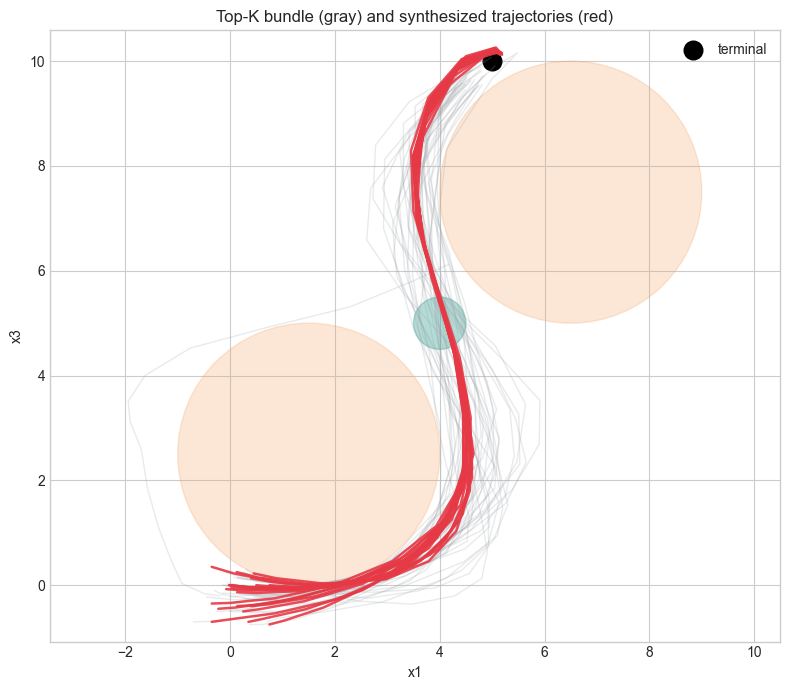

In [35]:
fig, ax = plt.subplots(figsize=(8, 7))

for tid in train_ids[:40]:
    X = selected[int(tid)]['X']
    ax.plot(X[:, 0], X[:, 2], color='#9AA0A6', alpha=0.22, linewidth=1)

for r in results[:20]:
    S = r['states']
    ax.plot(S[:, 0], S[:, 2], color='#E63946', alpha=0.9, linewidth=1.8)

for cyl in cfg.cylinders:
    c = plt.Circle((cyl.x, cyl.z), cyl.radius, color='#F4A261', alpha=0.25)
    ax.add_patch(c)
for wnd in cfg.windows:
    w = plt.Circle((wnd.x, wnd.z), wnd.radius, color='#2A9D8F', alpha=0.35)
    ax.add_patch(w)

ax.scatter([cfg.terminal_state[0]], [cfg.terminal_state[2]], marker='o', s=180, color='black', label='terminal')
ax.set_title('Top-K bundle (gray) and synthesized trajectories (red)')
ax.set_xlabel('x1')
ax.set_ylabel('x3')
ax.axis('equal')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## Терминальная ошибка

Terminal position error for first 10 rollouts:
[0.22617 0.2501  0.24673 0.22453 0.22179 0.23158 0.22651 0.21241 0.22879
 0.22797 0.19891 0.22547 0.23849 0.22928 0.22159 0.23148 0.23464 0.19736
 0.24201 0.24131]
Mean terminal error: 0.22786
Std terminal error: 0.01328
Max terminal error: 0.2501
Min terminal error: 0.19736


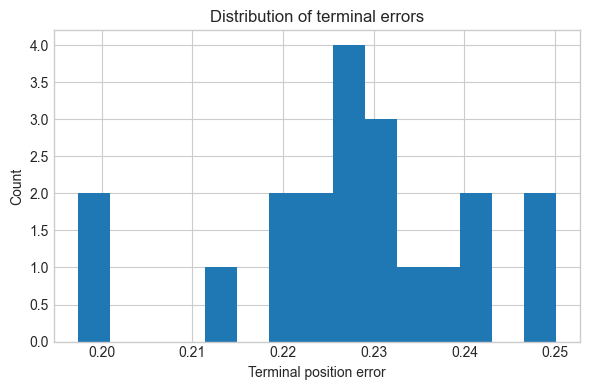

In [20]:
terminal_errors = []
for r in results[:20]:
    S = r['states']

    xT = S[-1]  # last state
    eT = np.linalg.norm(xT[:3] - cfg.terminal_state[:3])
    terminal_errors.append(eT)

terminal_errors = np.asarray(terminal_errors)

print("Terminal position error for first 10 rollouts:")
print(np.round(terminal_errors, 5))

print("Mean terminal error:", round(float(terminal_errors.mean()), 5))
print("Std terminal error:", round(float(terminal_errors.std()), 5))
print("Max terminal error:", round(float(terminal_errors.max()), 5))
print("Min terminal error:", round(float(terminal_errors.min()), 5))

plt.figure(figsize=(6, 4))
plt.hist(terminal_errors, bins=15)
plt.xlabel("Terminal position error")
plt.ylabel("Count")
plt.title("Distribution of terminal errors")
plt.tight_layout()
plt.show()

### Вывод

Синтезированный контроллер устойчиво воспроизводит целевые траектории и приводит систему в малую окрестность терминального состояния. Средняя ошибка по финальной позиции на 10 тестовых rollout’ах составляет около 0.23 при низком разбросе (std ≈ 0.011).
